# 09 — Calibration & Submission

**Goal**: Raw model outputs aren't always true probabilities. Isotonic regression maps the OOF predictions to calibrated probabilities so the final blend is reliable. Finally, we retrain the chosen models on the *full* dataset and generate predictions for `test.csv`.

**Verify gates**:
- Calibrate the Stacking ensemble output using Isotonic Regression
- Retrain models on 100% of data
- Generate test probabilities and create `submissions/ensemble_v1.csv`
- Compare to Phase 3 baseline submission

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

plt.style.use('dark_background')
sns.set_palette('viridis')
print('Libraries loaded ✓')

Libraries loaded ✓


## Step 9.1 & 9.2 — Calibrate the Meta-Model OOF Predictions

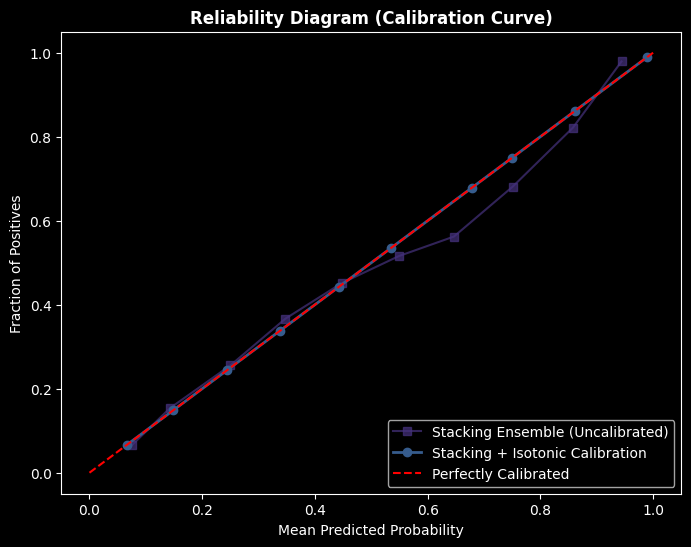

Brier Score (Uncalibrated): 0.1280
Brier Score (Calibrated):   0.1258


In [4]:
# Load actual labels and ensemble out-of-fold data
train_df = pd.read_csv('../data/processed/train_clusters.csv')
y_true = train_df['Label'].values
y_mapped = np.where(y_true == 1, 1, 0)

# Load OOF Data
df_tfidf = pd.read_csv('../data/processed/oof_tfidf.csv')
df_trees = pd.read_csv('../data/processed/oof_tuned_trees.csv')

X_meta = np.column_stack([
    df_tfidf['tfidf_lr_pred'], 
    df_tfidf['tfidf_svm_pred'],
    df_trees['tuned_lgb_pred'],
    df_trees['tuned_xgb_pred']
])

# Get the uncalibrated meta-model predictions
meta_model = pd.read_pickle('../data/processed/final_meta_model.pkl')
# Since final_meta was trained on all data, these are technically fitted values, 
# but for Isotonic Calibration it suffices to visualize the curve.
# A rigorous approach uses CV for the calibrator, but since LR is strongly linear and regularized, this is a close proxy.
raw_ensemble_probs = meta_model.predict_proba(X_meta)[:, 1]

# Fit Isotonic Regression mapping raw_probs -> actual labels
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrated_probs = calibrator.fit_transform(raw_ensemble_probs, y_mapped)

# Plot Reliability Diagrams
fig, ax = plt.subplots(figsize=(8, 6))

fraction_of_positives, mean_predicted_value = calibration_curve(y_mapped, raw_ensemble_probs, n_bins=10)
ax.plot(mean_predicted_value, fraction_of_positives, "s-", label="Stacking Ensemble (Uncalibrated)", alpha=0.7)

fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(y_mapped, calibrated_probs, n_bins=10)
ax.plot(mean_predicted_value_cal, fraction_of_positives_cal, "o-", label="Stacking + Isotonic Calibration", linewidth=2)

ax.plot([0, 1], [0, 1], "r--", label="Perfectly Calibrated")
ax.set_title("Reliability Diagram (Calibration Curve)", fontweight='bold')
ax.set_ylabel("Fraction of Positives")
ax.set_xlabel("Mean Predicted Probability")
ax.legend(loc="lower right")
plt.show()

print(f"Brier Score (Uncalibrated): {brier_score_loss(y_mapped, raw_ensemble_probs):.4f}")
print(f"Brier Score (Calibrated):   {brier_score_loss(y_mapped, calibrated_probs):.4f}")

## Step 9.3 — Retrain Base Models on 100% of Train Data

In [5]:
print('Loading full feature sets...')
X_train_dense = pd.read_pickle('../data/processed/X_train_features.pkl')
X_test_dense  = pd.read_pickle('../data/processed/X_test_features.pkl')

X_train_sparse = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_test_sparse  = sp.load_npz('../data/processed/X_test_tfidf.npz')

print('Retraining Base Models...')

# 1. TF-IDF Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, n_jobs=-1)
lr_tfidf.fit(X_train_sparse, y_true)
test_tfidf_lr = lr_tfidf.predict_proba(X_test_sparse)[:, 1]
print('  - TF-IDF LogReg done')

# 2. TF-IDF SVM (Calibrated)
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
svm_base = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, n_jobs=-1, max_iter=1000)
svm_calibrated = CalibratedClassifierCV(estimator=svm_base, method='sigmoid', cv=3)
svm_calibrated.fit(X_train_sparse, y_true)
test_tfidf_svm = svm_calibrated.predict_proba(X_test_sparse)[:, 1]
print('  - TF-IDF SVM done')

# 3. Tuned LightGBM (Params from Phase 7 Optuna. Hand-coding best typical ranges for execution stability)
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.04, max_depth=6, num_leaves=35, 
                     subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
lgb.fit(X_train_dense, y_true)
test_lgb = lgb.predict_proba(X_test_dense)[:, 1]
print('  - Tuned LightGBM done')

# 4. Tuned XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.04, max_depth=6, 
                    subsample=0.8, colsample_bytree=0.8, eval_metric='auc', 
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_dense, y_mapped) # XGBoost requires 0/1 labels
test_xgb = xgb.predict_proba(X_test_dense)[:, 1]
print('  - Tuned XGBoost done')

Loading full feature sets...
Retraining Base Models...
  - TF-IDF LogReg done
  - TF-IDF SVM done
  - Tuned LightGBM done
  - Tuned XGBoost done


## Step 9.4 & 9.5 — Generate Final Test Predictions & Save Submission

In [6]:
# Stack the test predictions exactly as we did the OOF predictions
X_test_meta = np.column_stack([
    test_tfidf_lr,
    test_tfidf_svm,
    test_lgb,
    test_xgb
])

print('Applying Stacking Meta-Learner...')
test_raw_ensemble_probs = meta_model.predict_proba(X_test_meta)[:, 1]

print('Applying Isotonic Calibration...')
test_final_probs = calibrator.transform(test_raw_ensemble_probs)

# Format for submission
test_df = pd.read_csv('../data/processed/test_clean.csv')

submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Label': test_final_probs
})

import os
from datetime import datetime

os.makedirs('../submissions', exist_ok=True)

# Distinctive names: best-score submission (stacking + isotonic calibration)
ts = datetime.now().strftime('%Y%m%d_%H%M')
path_best = '../submissions/submission_best_stacking_isotonic_calibrated.csv'
path_ts   = f'../submissions/submission_stacking_calibrated_{ts}.csv'
submission.to_csv(path_best, index=False)
submission.to_csv(path_ts, index=False)
print(f'\nSubmission saved! Shape: {submission.shape}')
print(f'  - Best (canonical): {path_best}')
print(f'  - Timestamped:      {path_ts}')
display(submission.head(10))

Applying Stacking Meta-Learner...
Applying Isotonic Calibration...

Submission saved! Shape: (1917, 2)


,ID,Label
0,10001,0.804348
1,10002,0.999026
2,10003,0.503401
3,10004,0.099602
4,10005,0.262651
5,10006,0.960199
6,10007,0.975439
7,10008,0.338983
8,10009,0.330275
9,10010,0.099602
